In [82]:
# https://judge.nitro-ai.org/competitions/nitro/rise-2026-final/2/view

import os
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
from tqdm.auto import tqdm
import torch
from torch import nn
import torch.nn.functional as F
from torchvision import models
from torch.utils.data import Dataset, DataLoader
from PIL import Image
from transformers import AutoModel, AutoTokenizer
from IPython.display import clear_output
from sklearn.model_selection import train_test_split
from sklearn.preprocessing import LabelEncoder
from itertools import chain

In [83]:
train = pd.read_json("/kaggle/input/datasets/abukanabek/rise-final-round-2026-radiologists-assistant/train_data.json")
test = pd.read_json("/kaggle/input/datasets/abukanabek/rise-final-round-2026-radiologists-assistant/test_data.json")

train['path'] = train['datapoint_id'].map(lambda x: '/kaggle/input/datasets/abukanabek/rise-final-round-2026-radiologists-assistant/train_images/train_images/' + x[:-3]+'.png')
test['path'] = test['datapoint_id'].map(lambda x: '/kaggle/input/datasets/abukanabek/rise-final-round-2026-radiologists-assistant/test_images/test_images/' + x[:-3]+'.png')

train.shape, test.shape

((1793, 4), (451, 3))

In [84]:
train.head()

,datapoint_id,question,answer,path
0,img_train_00000_q0,are regions of the brain infarcted?,yes,/kaggle/input/datasets/abukanabek/rise-final-r...
1,img_train_00001_q0,are the lungs normal appearing?,no,/kaggle/input/datasets/abukanabek/rise-final-r...
2,img_train_00002_q0,which organ system is abnormal in this image?,cardiovascular,/kaggle/input/datasets/abukanabek/rise-final-r...
3,img_train_00003_q0,is the lesion causing significant brainstem he...,no,/kaggle/input/datasets/abukanabek/rise-final-r...
4,img_train_00004_q0,how was this image taken?,mri,/kaggle/input/datasets/abukanabek/rise-final-r...


In [85]:
train['answer'].value_counts()

answer
no                   473
yes                  467
axial                 31
right                 20
pa                    14
                    ... 
both sides             1
lentiform              1
biconvex               1
epidural hematoma      1
irregular              1
Name: count, Length: 432, dtype: int64

In [86]:
threshold = 31
counts = train['answer'].value_counts()
alright_categories = counts[counts >= threshold].index
train = train[train['answer'].isin(alright_categories)].reset_index(drop=True)
train.shape, train['answer'].nunique()

((971, 4), 3)

In [87]:
le = LabelEncoder().fit(train['answer'])

train['answer'] = le.transform(train['answer'])

In [88]:
train['question'].map(lambda x: x.split()[0]).value_counts(normalize=True)

question
is          0.662204
are         0.144181
does        0.059732
can         0.035015
do          0.022657
what        0.020597
was         0.020597
in          0.008239
did         0.006179
has         0.004119
any         0.004119
which       0.003090
would       0.002060
anything    0.001030
will        0.001030
notice      0.001030
is/are      0.001030
have        0.001030
doe         0.001030
besides     0.001030
Name: proportion, dtype: float64

In [89]:
test['question'].map(lambda x: x.split()[0]).value_counts(normalize=True)

question
is           0.434590
what         0.203991
are          0.095344
where        0.066519
how          0.035477
which        0.033259
the          0.026608
does         0.026608
can          0.017738
in           0.011086
do           0.008869
was          0.008869
describe     0.004435
this         0.004435
diaphragm    0.002217
from         0.002217
size         0.002217
evidence     0.002217
has          0.002217
name         0.002217
term         0.002217
were         0.002217
did          0.002217
why          0.002217
Name: proportion, dtype: float64

In [90]:
train.head()

,datapoint_id,question,answer,path
0,img_train_00000_q0,are regions of the brain infarcted?,2,/kaggle/input/datasets/abukanabek/rise-final-r...
1,img_train_00001_q0,are the lungs normal appearing?,1,/kaggle/input/datasets/abukanabek/rise-final-r...
2,img_train_00003_q0,is the lesion causing significant brainstem he...,1,/kaggle/input/datasets/abukanabek/rise-final-r...
3,img_train_00009_q0,is this image in the transverse plane?,2,/kaggle/input/datasets/abukanabek/rise-final-r...
4,img_train_00010_q0,are there any pulmonary findings?,1,/kaggle/input/datasets/abukanabek/rise-final-r...


In [91]:
device = torch.device("cuda" if torch.cuda.is_available() else "cpu")
device

device(type='cuda')

In [92]:
train, valid = train_test_split(train, test_size=0.1, stratify=train['answer'], random_state=42)
train.shape, valid.shape

((873, 4), (98, 4))

In [93]:
class VisualTextualDataset(Dataset):
    def __init__(self, image_paths, texts, labels=None, transforms=None):
        self.image_paths = image_paths
        self.texts = texts
        self.labels = labels
        self.transforms = transforms
        
    def __len__(self):
        return len(self.image_paths)
        
    def __getitem__(self, idx):
        image = Image.open(self.image_paths[idx])
        text = self.texts[idx]
        if self.transforms:
            image = self.transforms(image)
        if not self.labels:
            return image, text
        label = self.labels[idx]
        return image, text, label

transforms = models.ResNet34_Weights.IMAGENET1K_V1.transforms()

train_ds = VisualTextualDataset(train['path'].tolist(), train['question'].tolist(), train['answer'].tolist(), transforms)
valid_ds = VisualTextualDataset(valid['path'].tolist(), valid['question'].tolist(), valid['answer'].tolist(), transforms)
test_ds = VisualTextualDataset(test['path'].tolist(), test['question'].tolist(), transforms=transforms)

BATCH_SIZE = 32

train_loader = DataLoader(train_ds, batch_size=BATCH_SIZE, shuffle=True)
valid_loader = DataLoader(valid_ds, batch_size=BATCH_SIZE, shuffle=False)
test_loader = DataLoader(test_ds, batch_size=BATCH_SIZE, shuffle=False)

len(train_loader), len(valid_loader), len(test_loader)

(28, 4, 15)

In [101]:
class VisualTextualClassifier(nn.Module):
    def __init__(self, num_classes, device):
        super().__init__()
        self.device = device
        self.tokenizer = AutoTokenizer.from_pretrained('distilbert-base-uncased')
        self.text_model = AutoModel.from_pretrained('distilbert-base-uncased')

        self.visual_model = models.resnet34(models.ResNet34_Weights)
        self.visual_model.fc = nn.Identity()

        self.visual_projector = nn.Sequential(
            nn.Linear(512, 256),
            nn.LayerNorm(256),
            nn.ReLU(inplace=True),
            nn.Dropout(0.0)
        )
        self.text_projector = nn.Sequential(
            nn.Linear(768, 256),
            nn.LayerNorm(256),
            nn.ReLU(inplace=True),
            nn.Dropout(0.0)
        )
        
        self.classifier = nn.Sequential(
            nn.Linear(256, num_classes)
        )

    def forward_text(self, texts):
        encoded_input = self.tokenizer(texts, padding=True, return_tensors='pt')
        encoded_input = {k: v.to(self.device) for k, v in encoded_input.items()}
        output = self.text_model(**encoded_input)
        hidden = output.last_hidden_state
        mask = encoded_input['attention_mask']
        mask_expanded = mask.unsqueeze(-1).expand(hidden.shape).float()
        embs = (mask_expanded * hidden).sum(1) / mask_expanded.sum(1)
        # embs = output.last_hidden_state[:, 0, :]
        return self.text_projector(embs)

    def forward_image(self, images):
        embs = self.visual_model(images)
        return self.visual_projector(embs)
    
    def forward(self, texts, images):
        text_proj, visual_proj = self.forward_text(texts), self.forward_image(images)
        embs = text_proj * visual_proj
        return self.classifier(embs)

In [102]:
def fit_one_epoch(model, optimizer, criterion, train_loader, device):
    model.train()
    total, rloss, correct = 0, 0, 0
    for images, texts, labels in (pbar := tqdm(train_loader, desc='Train Loader', leave=False)):
        batch_size = len(images)
        images, labels = images.to(device), labels.to(device)
        logits = model(texts, images)
        loss = criterion(logits, labels)

        optimizer.zero_grad()
        loss.backward()
        optimizer.step()

        total += batch_size
        rloss += loss.item() * batch_size
        correct += (torch.argmax(logits, dim=1)==labels).to(int).sum().item()

        cur_loss, cur_acc = rloss / total, correct / total
        pbar.set_postfix({
            'loss': f'{cur_loss:.6f}',
            'acc': f'{cur_acc:.6f}'
        })
        
    return cur_loss, cur_acc

@torch.no_grad()
def eval_one_epoch(model, criterion, valid_loader, device):
    model.eval()
    total, rloss, correct = 0, 0, 0
    for images, texts, labels in (pbar := tqdm(valid_loader, desc='Valid Loader', leave=False)):
        batch_size = len(images)
        images, labels = images.to(device), labels.to(device)
        logits = model(texts, images)
        loss = criterion(logits, labels)

        total += batch_size
        rloss += loss.item() * batch_size
        correct += (torch.argmax(logits, dim=1)==labels).to(int).sum().item()

        cur_loss, cur_acc = rloss / total, correct / total
        pbar.set_postfix({
            'loss': f'{cur_loss:.6f}',
            'acc': f'{cur_acc:.6f}'
        })
        
    return cur_loss, cur_acc

def plot_progress(history, plot_title):
    clear_output(wait=True)
    plt.figure(figsize=(15, 5))
    plt.suptitle(plot_title)

    plt.subplot(1, 2, 1)
    plt.title('Losses')
    plt.xlabel('epoch')
    plt.ylabel('loss')
    plt.plot(range(1, len(history['train_loss'])+1), history['train_loss'], label='train')
    plt.plot(range(1, len(history['valid_loss'])+1), history['valid_loss'], label='valid')
    plt.legend()

    plt.subplot(1, 2, 2)
    plt.title('Accuracies')
    plt.xlabel('epoch')
    plt.ylabel('accuracy')
    plt.plot(range(1, len(history['train_acc'])+1), history['train_acc'], label='train')
    plt.plot(range(1, len(history['valid_acc'])+1), history['valid_acc'], label='valid')
    plt.legend()

    plt.show()
    
def fit(model, optimizer, scheduler, criterion, train_loader, valid_loader, device, epochs, history=None):
    if not history:
        history = {
            'train_loss': [],
            'valid_loss': [],
            'train_acc': [],
            'valid_acc': []
        }

    for epoch in range(epochs):
        tloss, tacc = fit_one_epoch(model, optimizer, criterion, train_loader, device)
        vloss, vacc = eval_one_epoch(model, criterion, valid_loader, device)
        
        history['train_loss'].append(tloss)
        history['train_acc'].append(tacc)
        history['valid_loss'].append(vloss)
        history['valid_acc'].append(vacc)

        plot_progress(history, f'Epoch: {epoch+1}/{epochs} | LR: {[round(x, 6) for x in scheduler.get_last_lr()]}')
        
        scheduler.step()
        
    return history

In [103]:
epochs = 5

model = VisualTextualClassifier(train['answer'].nunique(), device).to(device)
optimizer = torch.optim.AdamW([
    {'params': chain(model.visual_model.parameters(), model.text_model.parameters()), 'lr': 2e-5},
    {'params': chain(model.visual_projector.parameters(), model.text_projector.parameters(), model.classifier.parameters()), 'lr': 1e-3}
])

scheduler = torch.optim.lr_scheduler.CosineAnnealingLR(optimizer, epochs)

criterion = nn.CrossEntropyLoss()

Loading weights:   0%|          | 0/100 [00:00<?, ?it/s]

DistilBertModel LOAD REPORT from: distilbert-base-uncased
Key                     | Status     |  | 
------------------------+------------+--+-
vocab_layer_norm.weight | UNEXPECTED |  | 
vocab_transform.weight  | UNEXPECTED |  | 
vocab_layer_norm.bias   | UNEXPECTED |  | 
vocab_transform.bias    | UNEXPECTED |  | 
vocab_projector.bias    | UNEXPECTED |  | 

Notes:
- UNEXPECTED	:can be ignored when loading from different task/architecture; not ok if you expect identical arch.
/usr/local/lib/python3.12/dist-packages/torchvision/models/_utils.py:135: UserWarning: Using 'weights' as positional parameter(s) is deprecated since 0.13 and may be removed in the future. Please use keyword parameter(s) instead.
  warnings.warn(
/usr/local/lib/python3.12/dist-packages/torchvision/models/_utils.py:223: UserWarning: Arguments other than a weight enum or `None` for 'weights' are deprecated since 0.13 and may be removed in the future. The current behavior is equivalent to passing `weights=ResNet34_Wei

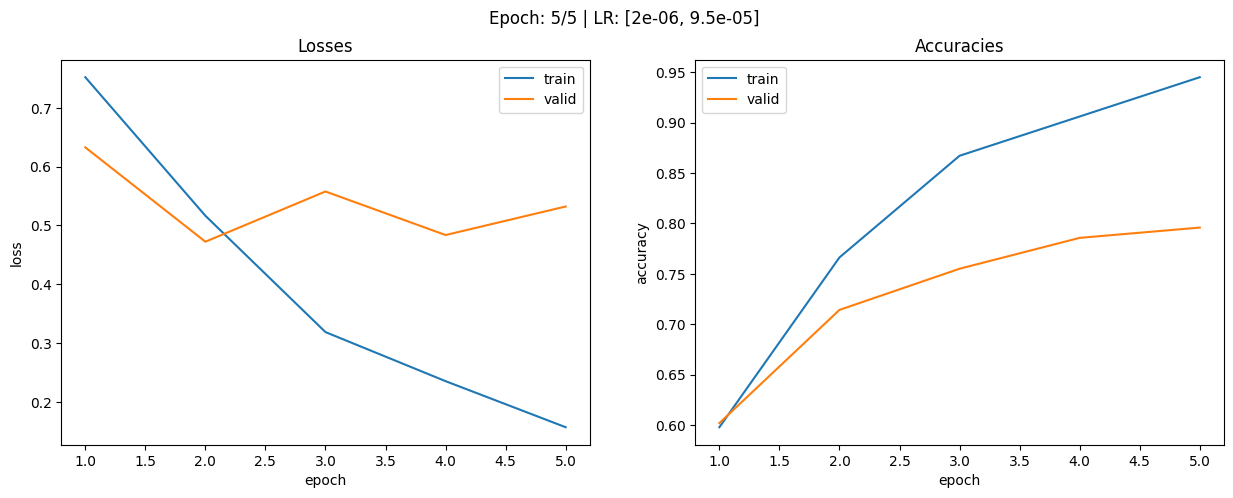

In [104]:
history = fit(model, optimizer, scheduler, criterion, train_loader, valid_loader, device, epochs)

In [ ]:
@torch.no_grad()
def inference(model, test_loader, device):
    model.eval()
    all_preds = []
    
    for images, texts in (pbar := tqdm(test_loader, desc='Test Loader', leave=False)):
        images = images.to(device)
        logits = model(texts, images)
        preds = logits.argmax(dim=-1).cpu().flatten().tolist()
        all_preds.extend(preds)
        
    return all_preds

predictions = inference(model, test_loader, device)

Test Loader:   0%|          | 0/15 [00:00<?, ?it/s]

In [ ]:
np.bincount(predictions)

In [ ]:
subm = pd.DataFrame({
    'subtaskID': 1,
    'datapointID': test['datapoint_id'],
    'answer': le.inverse_transform(predictions)
})

subm.to_csv("submission.csv", index=False)
subm.head()